Kelin Levine (EID: kel3258)  
May 4, 2026  
COE 311K - Engineering Computation, Spring 2026  
The University of Texas at Austin  
AI was not used in the creation of this report.

# Introduction & Model Selection

In this project, I will attempt to model the earthquake response of a generic 5-storey building
using two different numerical methods: Euler's Forward Method and Fourth-Order Runge-Kutta.
Suppose that as an earthquake occurs, it vibrates a building and the entire structure oscillates as
it shifts back and forth. When the earthquake ends, the building's oscillation will slow down as it
returns to its original position. The building's oscillation following the peak of the earthquake
(its response) can then be modeled as a damped mechanical system using the following second-order
ordinary differential equation:

$$\frac{d^2y}{dt^2}+2\zeta\omega\frac{dy}{dt}+\omega^2y=0$$

Where:
- $\zeta$ = damping ratio of the building (dimensionless)
- $\omega$ = natural frequency of the building (rad/s)
- $t$ = time elapsed since peak of displacement (s)
- $y(t)$ = displacement of the building (m)
- $\frac{dy}{dt}$ = velocity of the building (m/s)
- $\frac{d^2y}{dt^2}$ = acceleration of the building (m/s^2)

To model the displacement and velocity of the building, we must convert the second-order ODE to a
system of two first-order ODEs:

$$\frac{d^2y}{dt^2}=-\omega^2y-2\zeta\omega\frac{dy}{dt}$$

Let:
- $y_1=y$ (displacement)
- $y_2=\frac{dy}{dt}$ (velocity)

Then:
- $y_1'=\frac{dy}{dt}=y_2$
- $y_2'=\frac{d^2y}{dt^2}=-\omega^2y_1-2\zeta\omega y_2$

Then, by plugging in the building's state at maximum displacement from the earthquake for the initial
conditions, we can solve this system of ODEs to plot the displacement and velocity of the building over
time as it responds after the earthquake.

# Parameter Research & Justification

We are modeling the earthquake response of a generic 5-storey building. Specifically, we are interested
in the displacement and velocity of the building following the peak of the earthquake. We should expect
the displacement and velocity of the building to oscillate, and for this oscillation to decrease in
amplitude over time. I will attempt to plot the model by solving the above system of differential
equations using two different numerical methods: Euler's Forward Method and Fourth-Order Runge-Kutta (RK4).

| Parameter | Value | Source |
| :-: | :-: | :-: |
| $\zeta$ | 0.0125 | Constantinou [2] |
| $\omega$ | 3.17 rad/s | Constantinou [2] |
| $y_1(0)$ | 0.054 m | Faiz [1] |
| $y_2(0)$ | 0 m/s | Faiz [1] |
| Interval | 30 s |  |

| Method | Step Sizes (m, m/s) |
| :-: | :-: |
| Euler's Forward | 0.01, 0.008, 0.003, 0.0001 |
| RK4 | 0.9, 0.5, 0.3, 0.01 |

The seismic response of structures has been explored by Constantinou [2] with the following analysis of an
experimental study: "The addition of viscoelastic dampers resulted in increases of the natural frequency
and corresponding damping ratio of the 5-storey model structure from 3.17 Hz to 3.64 Hz and from 0.0125
to 0.15, respectively, at a temperature of 77 degrees F (25 degrees C). At 108 degrees F (42 degrees C)
temperature, the increases were from 3.17 Hz to 3.26 Hz and from 0.0125 to 0.053, respectively." This
analysis presents four sets of data for a model structure: with or without viscoelastic dampers, each at
two different temperatures. All of these options are realistic and therefore suitable for the model, so
I will choose to use the data for the model structure without viscoelastic dampers at 77 degrees F, as
this represents realistic properties of a simple building at an average temperature. This gives us a
damping ratio of $\zeta=0.0125$ and a natural frequency of $\omega=3.17\text{ rad/s}$ for our model.

Additionally, Table 2 of the study done by Faiz [1] provides data for the simulated seismic response of a
5-storey building. Specifically, in a seismic zone 5 setting analyzed using response spectrum analysis,
the building experiences a maximum storey displacement of 54mm (0.054m). In reality, various parameters
may affect the maximum displacement of the hypothetical building described by our model, but nevertheless
this gives us a realistic sample value to inform the initial conditions of our model. Thus, our model
will have initial conditions of $y_1(0)=0.054\text{ m}$ and $y_2(0)=0\text{ m/s}$ to represent the state
of the building at the peak of the earthquake: displacement is at its maximum (in meters), and velocity
is at 0 as this is a turning point in the oscillation. The model should then predict the building's damped oscillation and show how the peak amplitude lessens as time passes and the oscillation is damped over the
course of 30 seconds. This time interval is large enough to show the building settling over time and how
the various solution methods and step sizes behave as time passes. The model does not account for the
the continued force of the earthquake over the course of the building's damped oscillation as this is
beyond the scope of the model.

# Numerical Methods Implementation

In [1]:
"""Setup Numerical Implementation

This cell must be run before either following numerical implementation. This is
to load the necessary parameters and functions into the kernel. It should not
produce any output by itself.
"""


# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt


# Define the parameters
zeta = 0.0125  # Damping ratio
omega = 3.17   # Natural frequency

t_i = 0.0     # Start of interval
t_f = 30.0    # End of interval
y1_i = 0.054  # Initial condition of y1
y2_i = 0.0    # Initial condition of y2

h_values_euler = [0.01, 0.008, 0.003, 0.0001]  # Step sizes (Euler's Forward Method)
h_values_rk4 = [0.9, 0.5, 0.3, 0.01]           # Step sizes (RK4)


# Define the ODE functions
def f1(t, y1, y2):
    """Function representing the y1' ODE"""
    return y2


def f2(t, y1, y2):
    """Function representing the y2' ODE"""
    return -(omega*omega)*y1 - 2.0*zeta*omega*y2


In [2]:
"""Euler's Forward Method

Solve the above system of first-order differential equations using Euler's
Forward Method.

This implementation of Forward Euler's Method solves a system of first-order
differential equations by computing a series of steps over the interval. For
each step, it takes a slope for each function using the differential equations
and solutions at the previous step (starting at the initial conditions),
multiplies it by the step size for scale, and then adds it to the previous
solution to get the solution for the current step.

This cell runs after the 'Setup Numerical Implementation' cell in the kernel.
"""


# Euler's Forward Method Implementation
def forward_euler(f1, f2, y1_i, y2_i, t_i, t_f, h):
    # Create arrays to store t, y1, and y2 values
    t_values = np.arange(t_i, t_f + h, h)
    y1_values = np.zeros(len(t_values))
    y2_values = np.zeros(len(t_values))

    # Set initial conditions
    y1_values[0] = y1_i
    y2_values[0] = y2_i

    # Euler's Forward Method step loop
    for i in range(1, len(t_values)):
        # Current values
        t_n = t_values[i - 1]
        y1_n = y1_values[i - 1]
        y2_n = y2_values[i - 1]
        # Update solutions
        y1_values[i] = y1_n + h * f1(t_n, y1_n, y2_n)
        y2_values[i] = y2_n + h * f2(t_n, y1_n, y2_n)
    return t_values, y1_values, y2_values


In [3]:
"""Fourth-Order Runge-Kutta (RK4)

Solve the above system of first-order differential equations using Fourth-Order
Runge-Kutta (RK4).

This implementation of Fourth-Order Runge-Kutta solves a system of first-order
differential equations by computing a series of steps over the interval. For
each step, it takes four slopes for each function using the differential
equations and the solutions at the previous step (starting at the initial
conditions): the slope at the beginning of the step, two midpoint slopes, and
the slope at the end of the step, each using the previous slopes to estimate the
updated solutions. Then, it takes a weighted average of each set of slopes,
multiplied by step size for scale, and adds it to the previous solutions to get
the solutions for the current step.

This cell runs after the 'Setup Numerical Implementation' cell in the kernel.
"""


def runge_kutta_4(f1, f2, y1_i, y2_i, t_i, t_f, h):
    # Create arrays to store t, y1, and y2 values
    t_values = np.arange(t_i, t_f + h, h)
    y1_values = np.zeros(len(t_values))
    y2_values = np.zeros(len(t_values))

    # Set initial conditions
    y1_values[0] = y1_i
    y2_values[0] = y2_i

    # RK4 step loop
    for i in range(1, len(t_values)):
        # Calculate slopes
        t_n = t_values[i - 1]
        y1_n = y1_values[i - 1]
        y2_n = y2_values[i - 1]

        k1_v = t_n, y1_n, y2_n
        k1_y1 = h * f1(*k1_v)
        k1_y2 = h * f2(*k1_v)

        k2_v = t_n + h / 2, y1_n + k1_y1 / 2, y2_n + k1_y2 / 2
        k2_y1 = h * f1(*k2_v)
        k2_y2 = h * f2(*k2_v)

        k3_v = t_n + h / 2, y1_n + k2_y1 / 2, y2_n + k2_y2 / 2
        k3_y1 = h * f1(*k3_v)
        k3_y2 = h * f2(*k3_v)

        k4_v = t_n + h, y1_n + k3_y1, y2_n + k3_y2
        k4_y1 = h * f1(*k4_v)
        k4_y2 = h * f2(*k4_v)

        # Update y values using weighted average of slopes
        y1_values[i] = y1_n + (k1_y1 + 2 * k2_y1 + 2 * k3_y1 + k4_y1) / 6
        y2_values[i] = y2_n + (k1_y2 + 2 * k2_y2 + 2 * k3_y2 + k4_y2) / 6
    return t_values, y1_values, y2_values


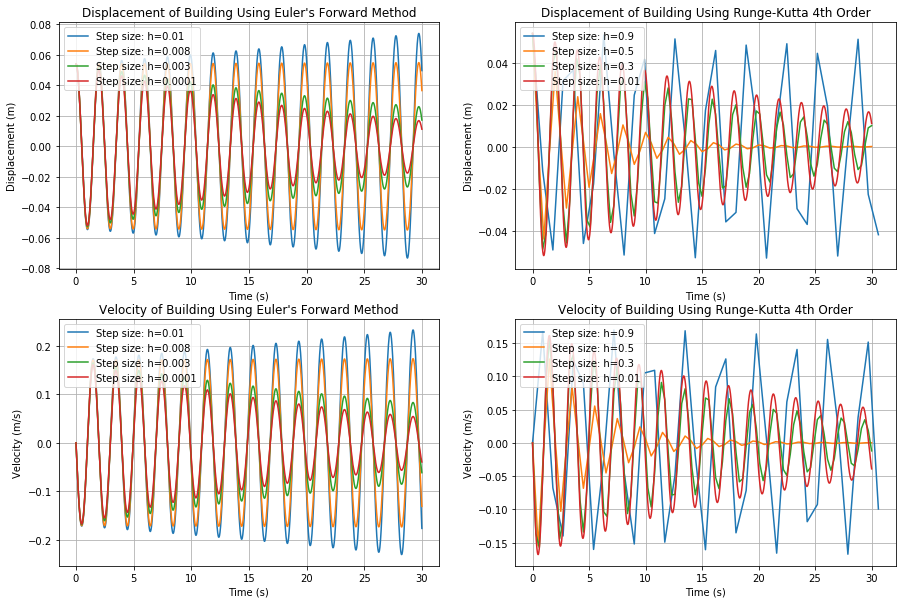

In [4]:
"""Solution Plotter

This will solve and plot the solution of the system of first-order differential
equations using the above numerical implementations.

This cell must run after both preceding cells in the kernel.
"""


def plot_solution(f, title, h_values, ncol, i):
    # Collect and configure subplots
    plt1 = plt.subplot(2, ncol, i)
    plt1.set_title(f'Displacement of Building Using {title}')
    plt1.set_xlabel('Time (s)')
    plt1.set_ylabel('Displacement (m)')
    plt1.grid(True)

    plt2 = plt.subplot(2, ncol, i+ncol)
    plt2.set_title(f'Velocity of Building Using {title}')
    plt2.set_xlabel('Time (s)')
    plt2.set_ylabel('Velocity (m/s)')
    plt2.grid(True)

    # Run the solver and plot
    for h in h_values:
        t_values, y1_values, y2_values = f(f1, f2, y1_i, y2_i, t_i, t_f, h)
        plt1.plot(t_values, y1_values, label=f'Step size: h={h}')
        plt2.plot(t_values, y2_values, label=f'Step size: h={h}')

    # Finish plotting
    plt1.legend(loc='upper left')
    plt2.legend(loc='upper left')


# Setup plot
plt.figure(figsize=(15, 10))

# Solve and plot solutions
plot_solution(forward_euler, "Euler's Forward Method", h_values_euler, 2, 1)
plot_solution(runge_kutta_4, "Runge-Kutta 4th Order", h_values_rk4, 2, 2)

# Show plot
plt.show()


# Solutions & Comparison

Based on the above plots of the Euler's Forward Method and Fourth-Order Runge-Kutta solutions to the system,
we can see that the solutions from these methods converge to similar results at relatively low step sizes,
but differ in how they behave at higher step sizes. Specifically, with Euler's Forward Method, the oscillation
appears to dampen less as step size increases, eventually becoming unstable when the oscillation starts to
grow over time instead of shrink. RK4, on the other hand, appears to dampen faster as step size increases,
becoming unstable when step size is high enough that it suddenly becomes erratic.

# Stability Analysis

## Step Size Investigation

For both methods, as step size increases, solution accuracy decreases, and vice versa.
Notably, Fourth-Order Runge-Kutta remains stable and accurate at much higher step sizes
than Euler's Forward Method, requiring far fewer steps to achieve a similarly accurate result.

With Euler's Forward Method, as step size increases, the solution dampens less, resulting in
an oscillation that achieves higher amplitude over time. The maximum stable step size for
this method is approximately $h=0.008$: when the step size is larger than this, the solution
becomes unstable because the amplitude of oscillation grows indefinitely over time instead of
shrinking as a damped mechanical system should.

With Fourth-Order Runge-Kutta, as step size increases, the solutions dampens more, resulting
in an oscillation that achieves lower amplitude over time. The maximum stable step size for
this method is approximately $h=0.5$: when the step size is larger than this, the solution
becomes unstable because the oscillation takes and awkward shape and quickly vanishes, and
at very high step sizes, the solution becomes erratic.

## Error Quantification

We can solve the governing second-order ODE to find a general solution to the system for $\zeta<1$:

$$\phi=\sqrt{-\left(\zeta\right)^{2}+1}$$

$$y\left(t\right)=\exp\left(-\zeta\omega t\right)\left(C_{1}\cos\left(\omega t\phi\right)+C_{2}\sin\left(\omega t\phi\right)\right)$$

$$y'\left(t\right)=\omega\exp\left(-\zeta\omega t\right)\left(C_{1}\left(-\sin\left(\omega t\phi\right)\phi-\zeta\cos\left(\omega t\phi\right)\right)+C_{2}\left(\cos\left(\omega t\phi\right)\phi-\zeta\sin\left(\omega t\phi\right)\right)\right)$$

For the analytical solution with our parameters and initial conditions, the constants are:

$$C_{1}=0.054,\quad C_{2}\approx 0.000675$$

The derivation of this solution is beyond the scope of this report and thus has been omitted.

In [5]:
"""Analytical Solution Solver

Implements a function to solve the system exactly using the analytical solution.

The solution is programmed into the implementation directly and is NOT based on
the ODE functions in the 'Setup Numerical Implementation' cell.
"""


# Solve using analytical solution (system of equations is hardcoded)
def analytical_solution(t_i, t_f, h):
    # Create array to store t values
    t_values = np.arange(t_i, t_f + h, h)

    # Solve parts of system
    C1, C2 = 0.054, 0.000675
    phi1 = np.sqrt(-(zeta**2)+1)
    phi2 = np.exp(-zeta*omega*t_values)
    phi3 = np.cos(omega*phi1*t_values)
    phi4 = np.sin(omega*phi1*t_values)

    # Solve system
    y1_values = phi2*(C1*phi3 + C2*phi4)
    y2_values = omega*phi2*(C1*(-phi1*phi4-zeta*phi3) + C2*(phi1*phi3-zeta*phi4))
    return t_values, y1_values, y2_values


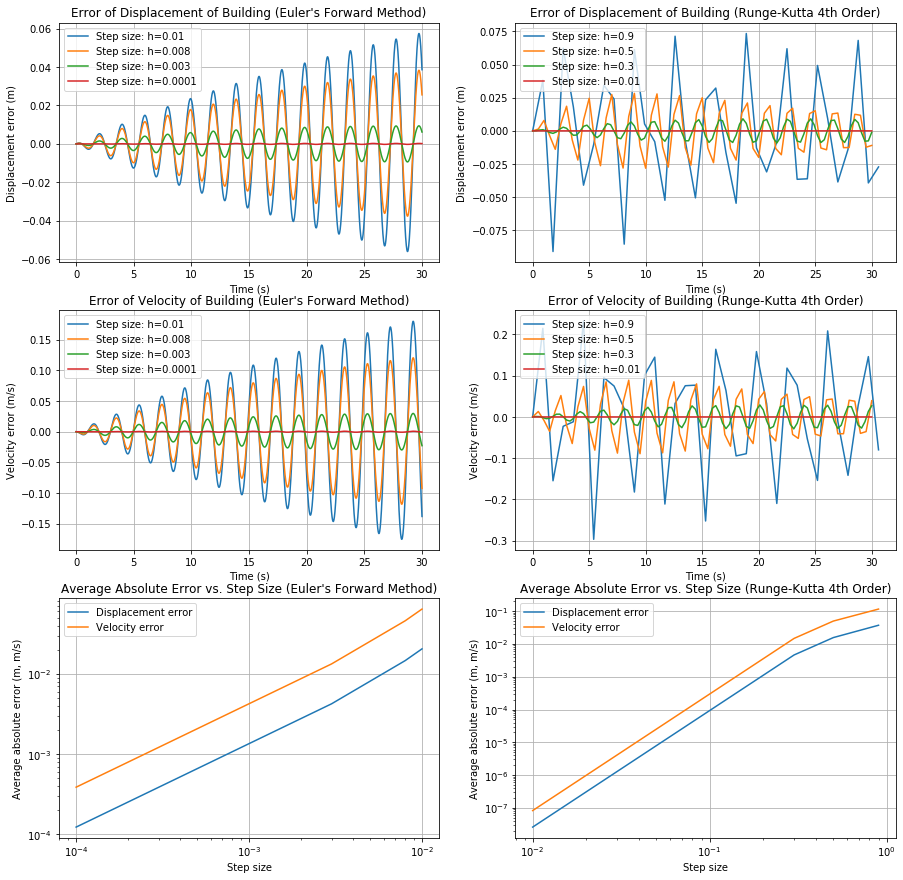

In [6]:
"""Error Quantification

Compare the error of the previous methods to the analytical solution.

This cell runs after the 'Setup Numerical Implementation' and
'Analytical Solution Solver' cells in the kernel.
"""


def plot_error(f, title, h_values, ncol, i):
    # Collect and configure subplots
    plt1 = plt.subplot(3, ncol, i)
    plt1.set_title(f'Error of Displacement of Building ({title})')
    plt1.set_xlabel('Time (s)')
    plt1.set_ylabel('Displacement error (m)')
    plt1.grid(True)

    plt2 = plt.subplot(3, ncol, i+ncol)
    plt2.set_title(f'Error of Velocity of Building ({title})')
    plt2.set_xlabel('Time (s)')
    plt2.set_ylabel('Velocity error (m/s)')
    plt2.grid(True)

    plt3 = plt.subplot(3, ncol, i+2*ncol)
    plt3.set_title(f'Average Absolute Error vs. Step Size ({title})')
    plt3.set_xlabel('Step size')
    plt3.set_ylabel('Average absolute error (m, m/s)')
    plt3.grid(True)

    # Run the solver and plot
    avg_y1_err = []
    avg_y2_err = []
    for h in h_values:
        t_values, y1_values, y2_values = f(f1, f2, y1_i, y2_i, t_i, t_f, h)
        _, y1_exact, y2_exact = analytical_solution(t_i, t_f, h)
        y1_err = y1_values-y1_exact
        y2_err = y2_values-y2_exact
        avg_y1_err.append(np.mean(np.abs(y1_err)))
        avg_y2_err.append(np.mean(np.abs(y2_err)))
        plt1.plot(t_values, y1_err, label=f'Step size: h={h}')
        plt2.plot(t_values, y2_err, label=f'Step size: h={h}')

    # Plot average error vs. step size
    plt3.loglog(h_values, avg_y1_err, label="Displacement error")
    plt3.loglog(h_values, avg_y2_err, label="Velocity error")

    # Finish plotting
    plt1.legend(loc='upper left')
    plt2.legend(loc='upper left')
    plt3.legend(loc='upper left')


# Setup plot
plt.figure(figsize=(15, 15))

# Solve and plot solutions
plot_error(forward_euler, "Euler's Forward Method", h_values_euler, 2, 1)
plot_error(runge_kutta_4, "Runge-Kutta 4th Order", h_values_rk4, 2, 2)

# Show plot
plt.show()


As we can see from the log-log plots of error vs. step size, the convergence rates are
as we should expect. Euler's Forward Method, with one slope per step, has a slope of
approximately 1, and RK4, with four slopes per step, has a slope of approximately 4.

## Physical Interpretation

Numerical instabilities lead to non-physical results. In a damped system, the solution
is supposed to decay over time as the oscillation is damped, but when a numerical
instability occurs, the solution grows instead. In the context of a building's earthquake
response, this numerical instability would imply that the building does not settle, but
instead vibrates more intensely after the earthquake ends. In reality, the phyiscal
results are that the building's oscillation should decay as it comes to rest. This is
what occurs in numerically stable solutions.

# Conclusions

In conclusion, both Euler's Forward Method and Fourth-Order Runge-Kutta were able
to accurately model the earthquake response of a 5-storey building when given
sufficiently low step sizes, but RK4 performed better overall because it was able
to produce an accurate solution with a much larger step size than Euler's Forward
Method.

For both methods, the step size offers a trade-off between computational cost and
accuracy. Smaller step sizes generally produce more accurate solutions than larger
step sizes, but require more iterations, which increases the computational cost of
computing the solution. RK4 was able to produce an accurate solution with a step
size of $h=0.01$, while Euler's Forward Method was unstable at this step size and
needed a much smaller step size of $h=0.0001$ to produce an accurate solution.

Because RK4 calculates four slopes for each step whereas Euler's Forward Method
only calculates one, each step of RK4 is approximately four times as costly as
each step of Euler's Forward Method, but RK4 is still more efficient overall for
computing an accurate solution because it only needs to compute 1 step for every
approximately 100 steps that Euler's Forward Method would have to compute to
produce a similarly accurate solution.

# Citations

[1] M. Faiz and R. Kumar, “Comparative Effectiveness of Equivalent Static Analysis & Response Spectrum Analysis in Extreme Seismic Zones,” IOP Conference Series: Earth and Environmental Science, vol. 1110, no. 1, Feb. 2023, doi: https://doi.org/10.1088/1755-1315/1110/1/012013.

Online link: https://www.researchgate.net/publication/368561853_Comparative_Effectiveness_of_Equivalent_Static_Analysis_Response_Spectrum_Analysis_in_Extreme_Seismic_Zones

[2] M. C. Constantinou and M. D. Symans, “Seismic Response of Structures with Supplemental Damping,” The Structural Design of Tall Buildings, vol. 2, no. 2, pp. 77–92, Jun. 1993, doi: https://doi.org/10.1002/tal.4320020202.

Online link: https://www.taylordevices.com/wp-content/uploads/21-Seismic-Response-of-Structures.pdf